In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.timeseries import LombScargle

project_root = Path("/home/maju/projeto/LS5039")
sys.path.append(str(project_root / "src"))

from periodograma import calcular_periodograma_medio_gti

# Parâmetros
ano = "2022"
binagem = "b10s" 
energia = "10_30"

arq_entrada = project_root / "data" / "processed" / f"sub_{ano}_{binagem}_{energia}.lc"

if not arq_entrada.exists():
    raise FileNotFoundError(f"Ficheiro não encontrado: {arq_entrada}")

with fits.open(arq_entrada) as hdul:
    data = hdul[1].data
    time = np.asarray(data['TIME'], dtype=float)
    rate = np.asarray(data['RATE'], dtype=float)
    err = np.asarray(data['ERROR'], dtype=float) if 'ERROR' in data.names else None

print(f"Ficheiro carregado com sucesso: {arq_entrada.name}")
print(f"Número de pontos: {len(time)}")

Ficheiro carregado com sucesso: sub_2022_b10s_10_30.lc
Número de pontos: 19634


In [2]:
from periodograma import (
    calcular_periodograma_medio_gti,
    extrair_segmentos_gti,
    calcular_limiares_fap_scargle,
    calcular_funcao_janela,
    filtrar_periodograma
)

In [3]:
# chegagem da binagem

print("Primeiros 15 valores de tempo:", time[:15])
print("Primeiros 15 passos temporais (dt):", np.diff(time)[:15])

Primeiros 15 valores de tempo: [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130.
 140.]
Primeiros 15 passos temporais (dt): [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]


In [4]:
dt_mediano = np.median(np.diff(time))

min_p_seg_teorico = 2.0 * dt_mediano
min_p_seg = max(2.0, min_p_seg_teorico)  # Nyquist
max_p_seg = 120.0 
limite_gap = 600  # 10 minutos

print(f"--- Parâmetros ---")
print(f"Espaçamento mediano: {dt_mediano:.2f} s")
print(f"Menor período mínimo (Nyquist): {min_p_seg:.2f} s (Fmax = {1/min_p_seg:.4f} Hz)")
print(f"Maior período considerado: {max_p_seg:.2f} s (Fmin = {1/max_p_seg:.4f} Hz)")

freq_hz, power_med, best_freq_hz, best_p_seg, n_gtis, info_gtis = calcular_periodograma_medio_gti(
    time, rate, err, 
    limite_gap_seg=limite_gap,  
    min_p_seg=min_p_seg, 
    max_p_seg=max_p_seg,
    min_pontos=30
)

print(f"\nJanelas orbitais: {n_gtis}")
print(f"Frequência de maior pico: {best_freq_hz:.5f} Hz")
print(f"Período correspondente: {best_p_seg:.2f} segundos")

df_gtis = pd.DataFrame(info_gtis)
caminho_csv = project_root / "data" / "processed" / f"resumo_gtis_{ano}_{binagem}_10min.csv"
df_gtis.to_csv(caminho_csv, index=False)

display(df_gtis.head())

--- Parâmetros ---
Espaçamento mediano: 10.00 s
Menor período mínimo (Nyquist): 20.00 s (Fmax = 0.0500 Hz)
Maior período considerado: 120.00 s (Fmin = 0.0083 Hz)
Periodograma médio calculado sobre 64 janelas orbitais (GTIs).

Janelas orbitais: 64
Frequência de maior pico: 0.01757 Hz
Período correspondente: 56.92 segundos


,GTI,T_Start,T_Stop,Duracao_min,N_Pontos
0,1,0.0,3140.0,52.33,133
1,2,5700.0,8940.0,54.00,150
2,3,11440.0,14720.0,54.67,146
3,4,17240.0,20530.0,54.83,138
4,5,23050.0,26290.0,54.00,156


In [5]:
print("Existem NaNs na potência?", np.isnan(power_med).any())
print("Primeiros 10 valores de potência:", power_med[:10])

Existem NaNs na potência? False
Primeiros 10 valores de potência: [0.01063188 0.01069784 0.01076801 0.01084206 0.01091966 0.01100049
 0.01108418 0.01117039 0.01125876 0.01134893]


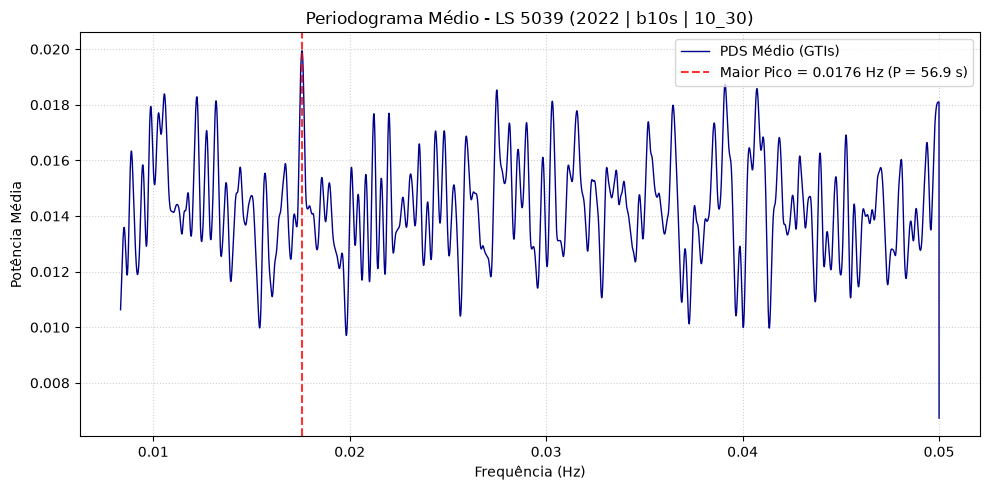

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(freq_hz, power_med, color='darkblue', lw=1.0, label='PDS Médio (GTIs)')
plt.axvline(best_freq_hz, color='red', ls='--', alpha=0.8, 
            label=f'Maior Pico = {best_freq_hz:.4f} Hz (P = {best_p_seg:.1f} s)')

plt.xlabel('Frequência (Hz)')
plt.ylabel('Potência Média')
plt.title(f'Periodograma Médio - LS 5039 ({ano} | {binagem} | {energia})')
plt.grid(True, ls=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

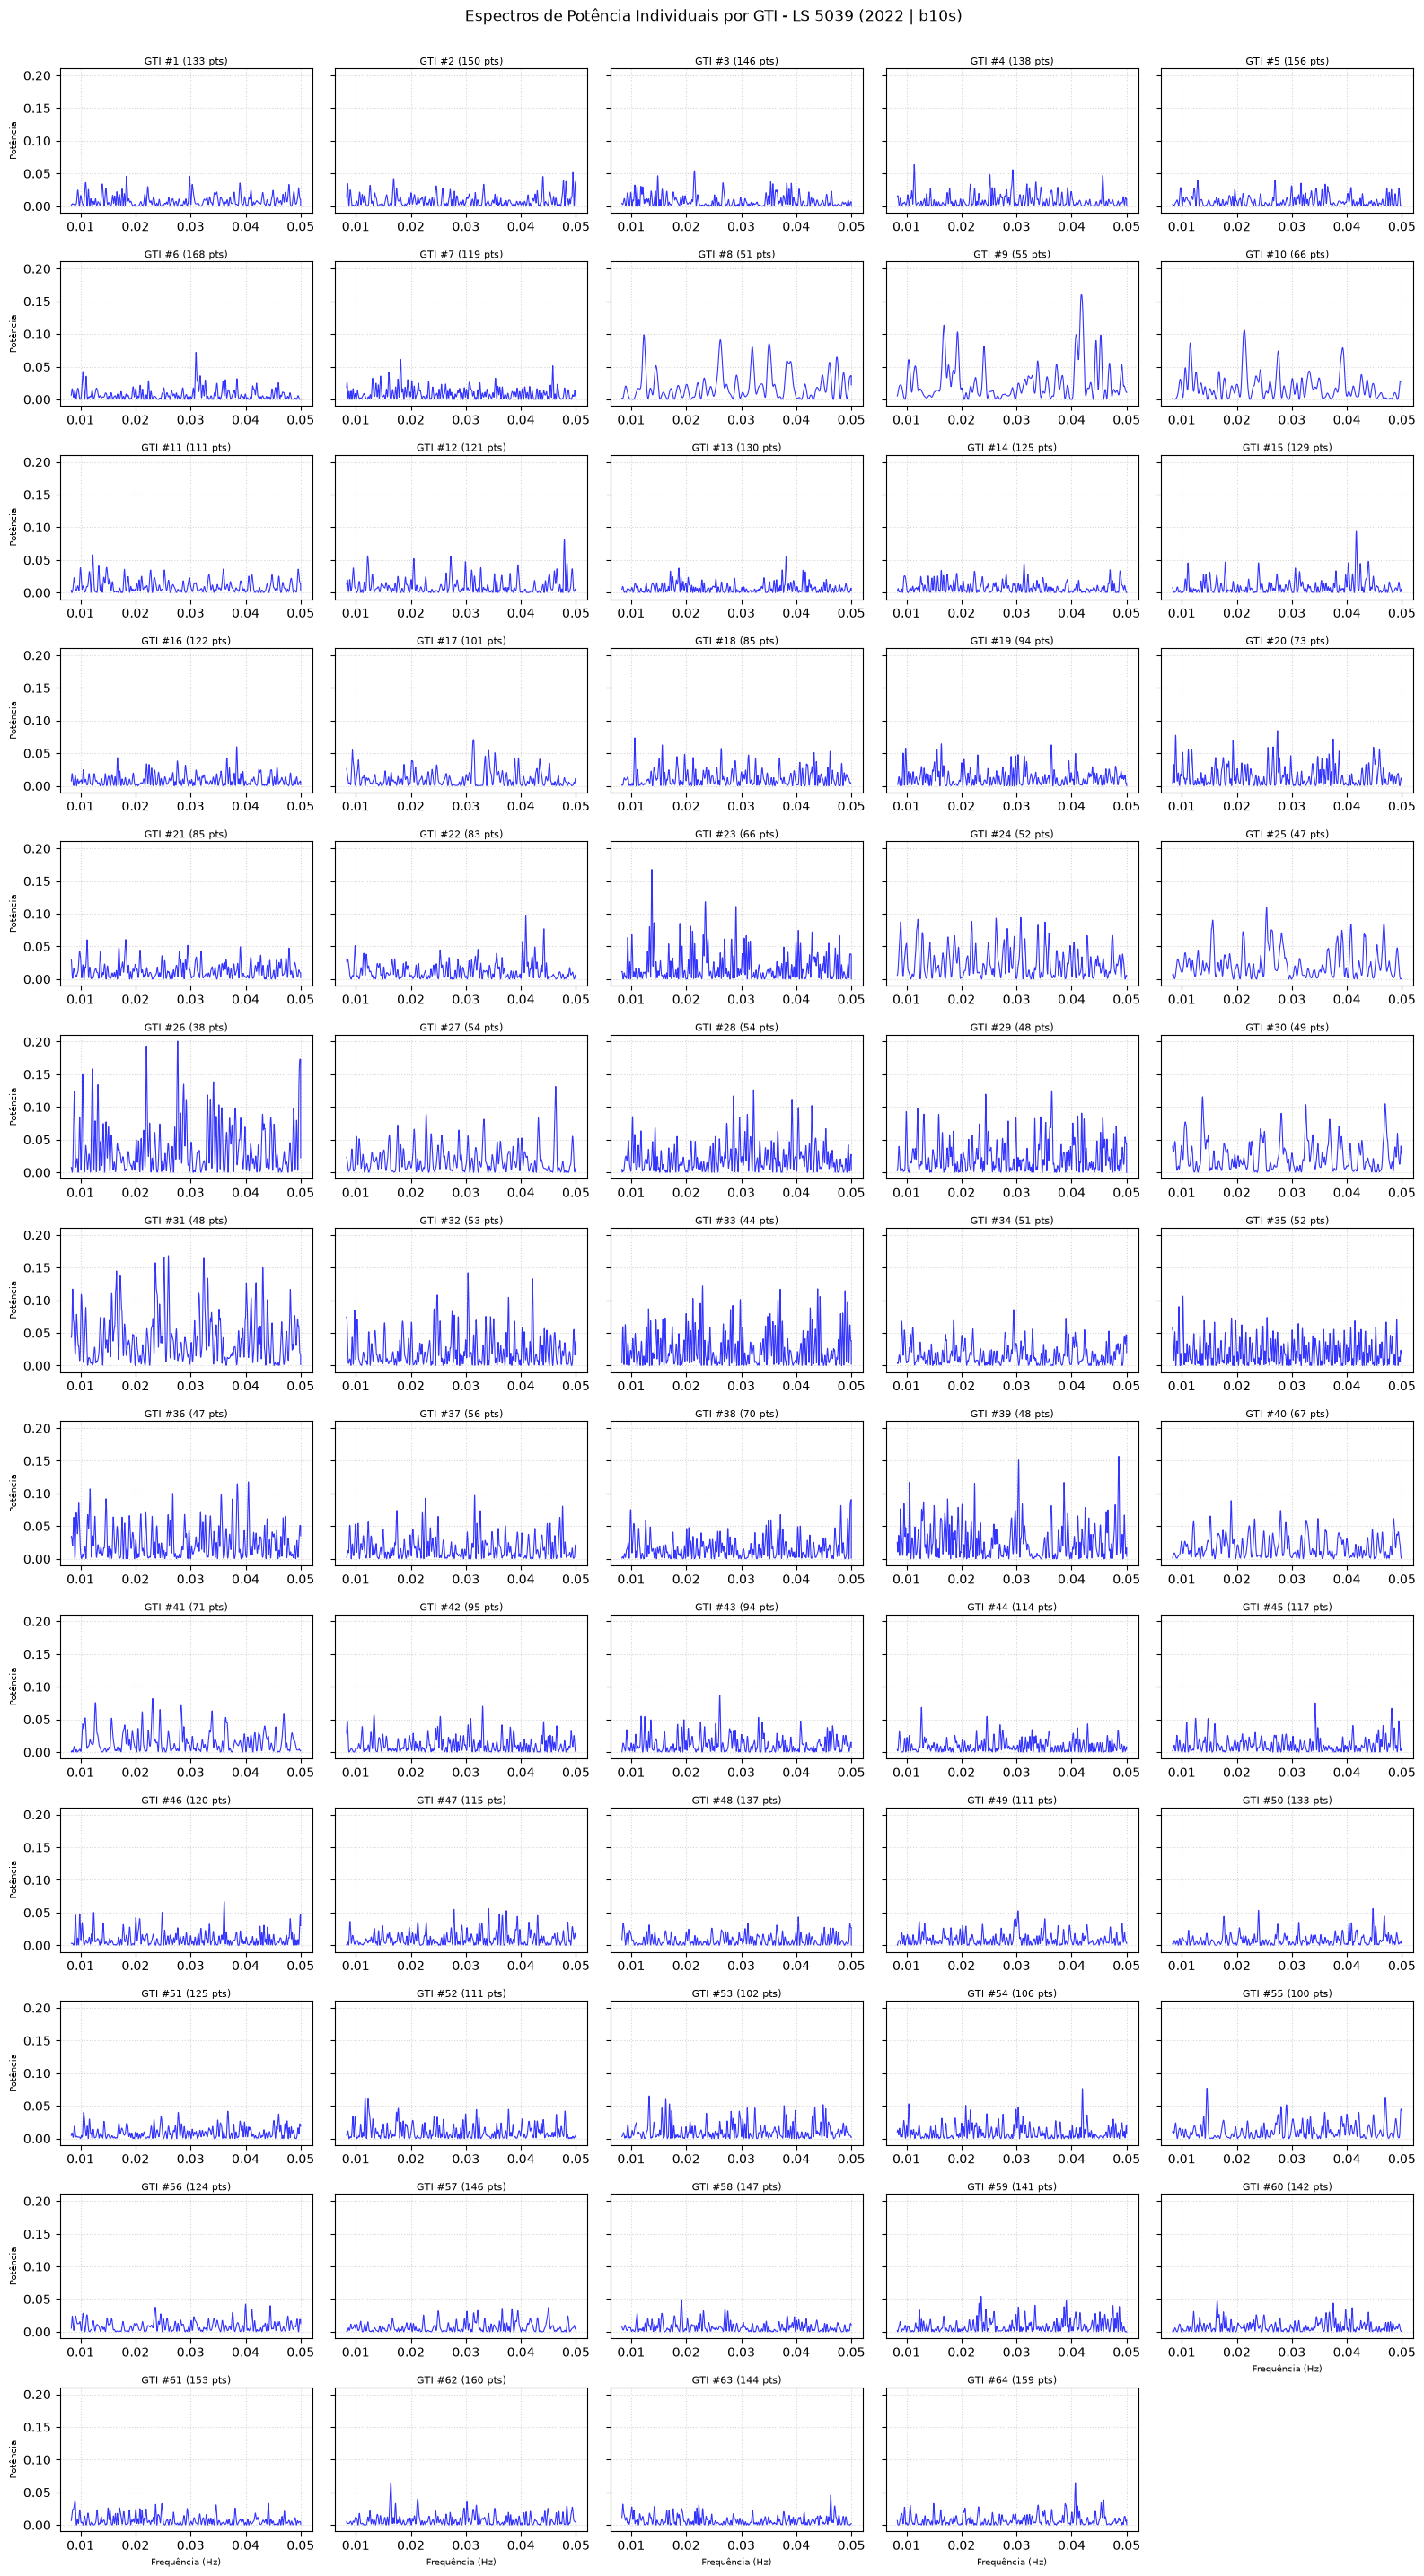

In [7]:
def extrair_segmentos_gti(time, rate, err=None, limite_gap_seg=600, min_pontos=30):
   
    dt = np.diff(time)
    quebras = np.where(dt > limite_gap_seg)[0]
    
    indices_inicio = np.insert(quebras + 1, 0, 0)
    indices_fim = np.append(quebras, len(time) - 1)
    
    segmentos = []
    for start, end in zip(indices_inicio, indices_fim):
        t_seg = time[start:end + 1]
        r_seg = rate[start:end + 1]
        e_seg = err[start:end + 1] if err is not None else None
        
        mask_seg = (r_seg > 0) & ~np.isnan(r_seg)
        if np.sum(mask_seg) >= min_pontos:
            segmentos.append((t_seg[mask_seg], r_seg[mask_seg], e_seg[mask_seg] if e_seg is not None else None))
            
    return segmentos

segmentos = extrair_segmentos_gti(time, rate, err, limite_gap_seg=limite_gap)
n_seg = len(segmentos)

f_min, f_max = 1.0 / max_p_seg, 1.0 / min_p_seg
freq_grid = np.linspace(f_min, f_max, 10000)

ncols = 5
nrows = int(np.ceil(n_seg / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.2), sharey=True)
axes = axes.flatten()

for i, (t_seg, r_seg, e_seg) in enumerate(segmentos):
    ax = axes[i]
    
    ls = LombScargle(t_seg, r_seg, e_seg)
    power = ls.power(freq_grid)
    
    ax.plot(freq_grid, power, 'b-', lw=0.8, alpha=0.8)

    #ax.axvline(best_freq_hz, color='red', ls=':', lw=0.8, alpha=0.7)
        
    ax.set_title(f'GTI #{i+1} ({len(t_seg)} pts)', fontsize=8, pad=3)
    ax.grid(True, ls=':', alpha=0.5)
    
    if i % ncols == 0:
        ax.set_ylabel('Potência', fontsize=7)
    if i >= n_seg - ncols:
        ax.set_xlabel('Frequência (Hz)', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Espectros de Potência Individuais por GTI - LS 5039 ({ano} | {binagem})', fontsize=12, y=1.002)
plt.tight_layout()
plt.show()

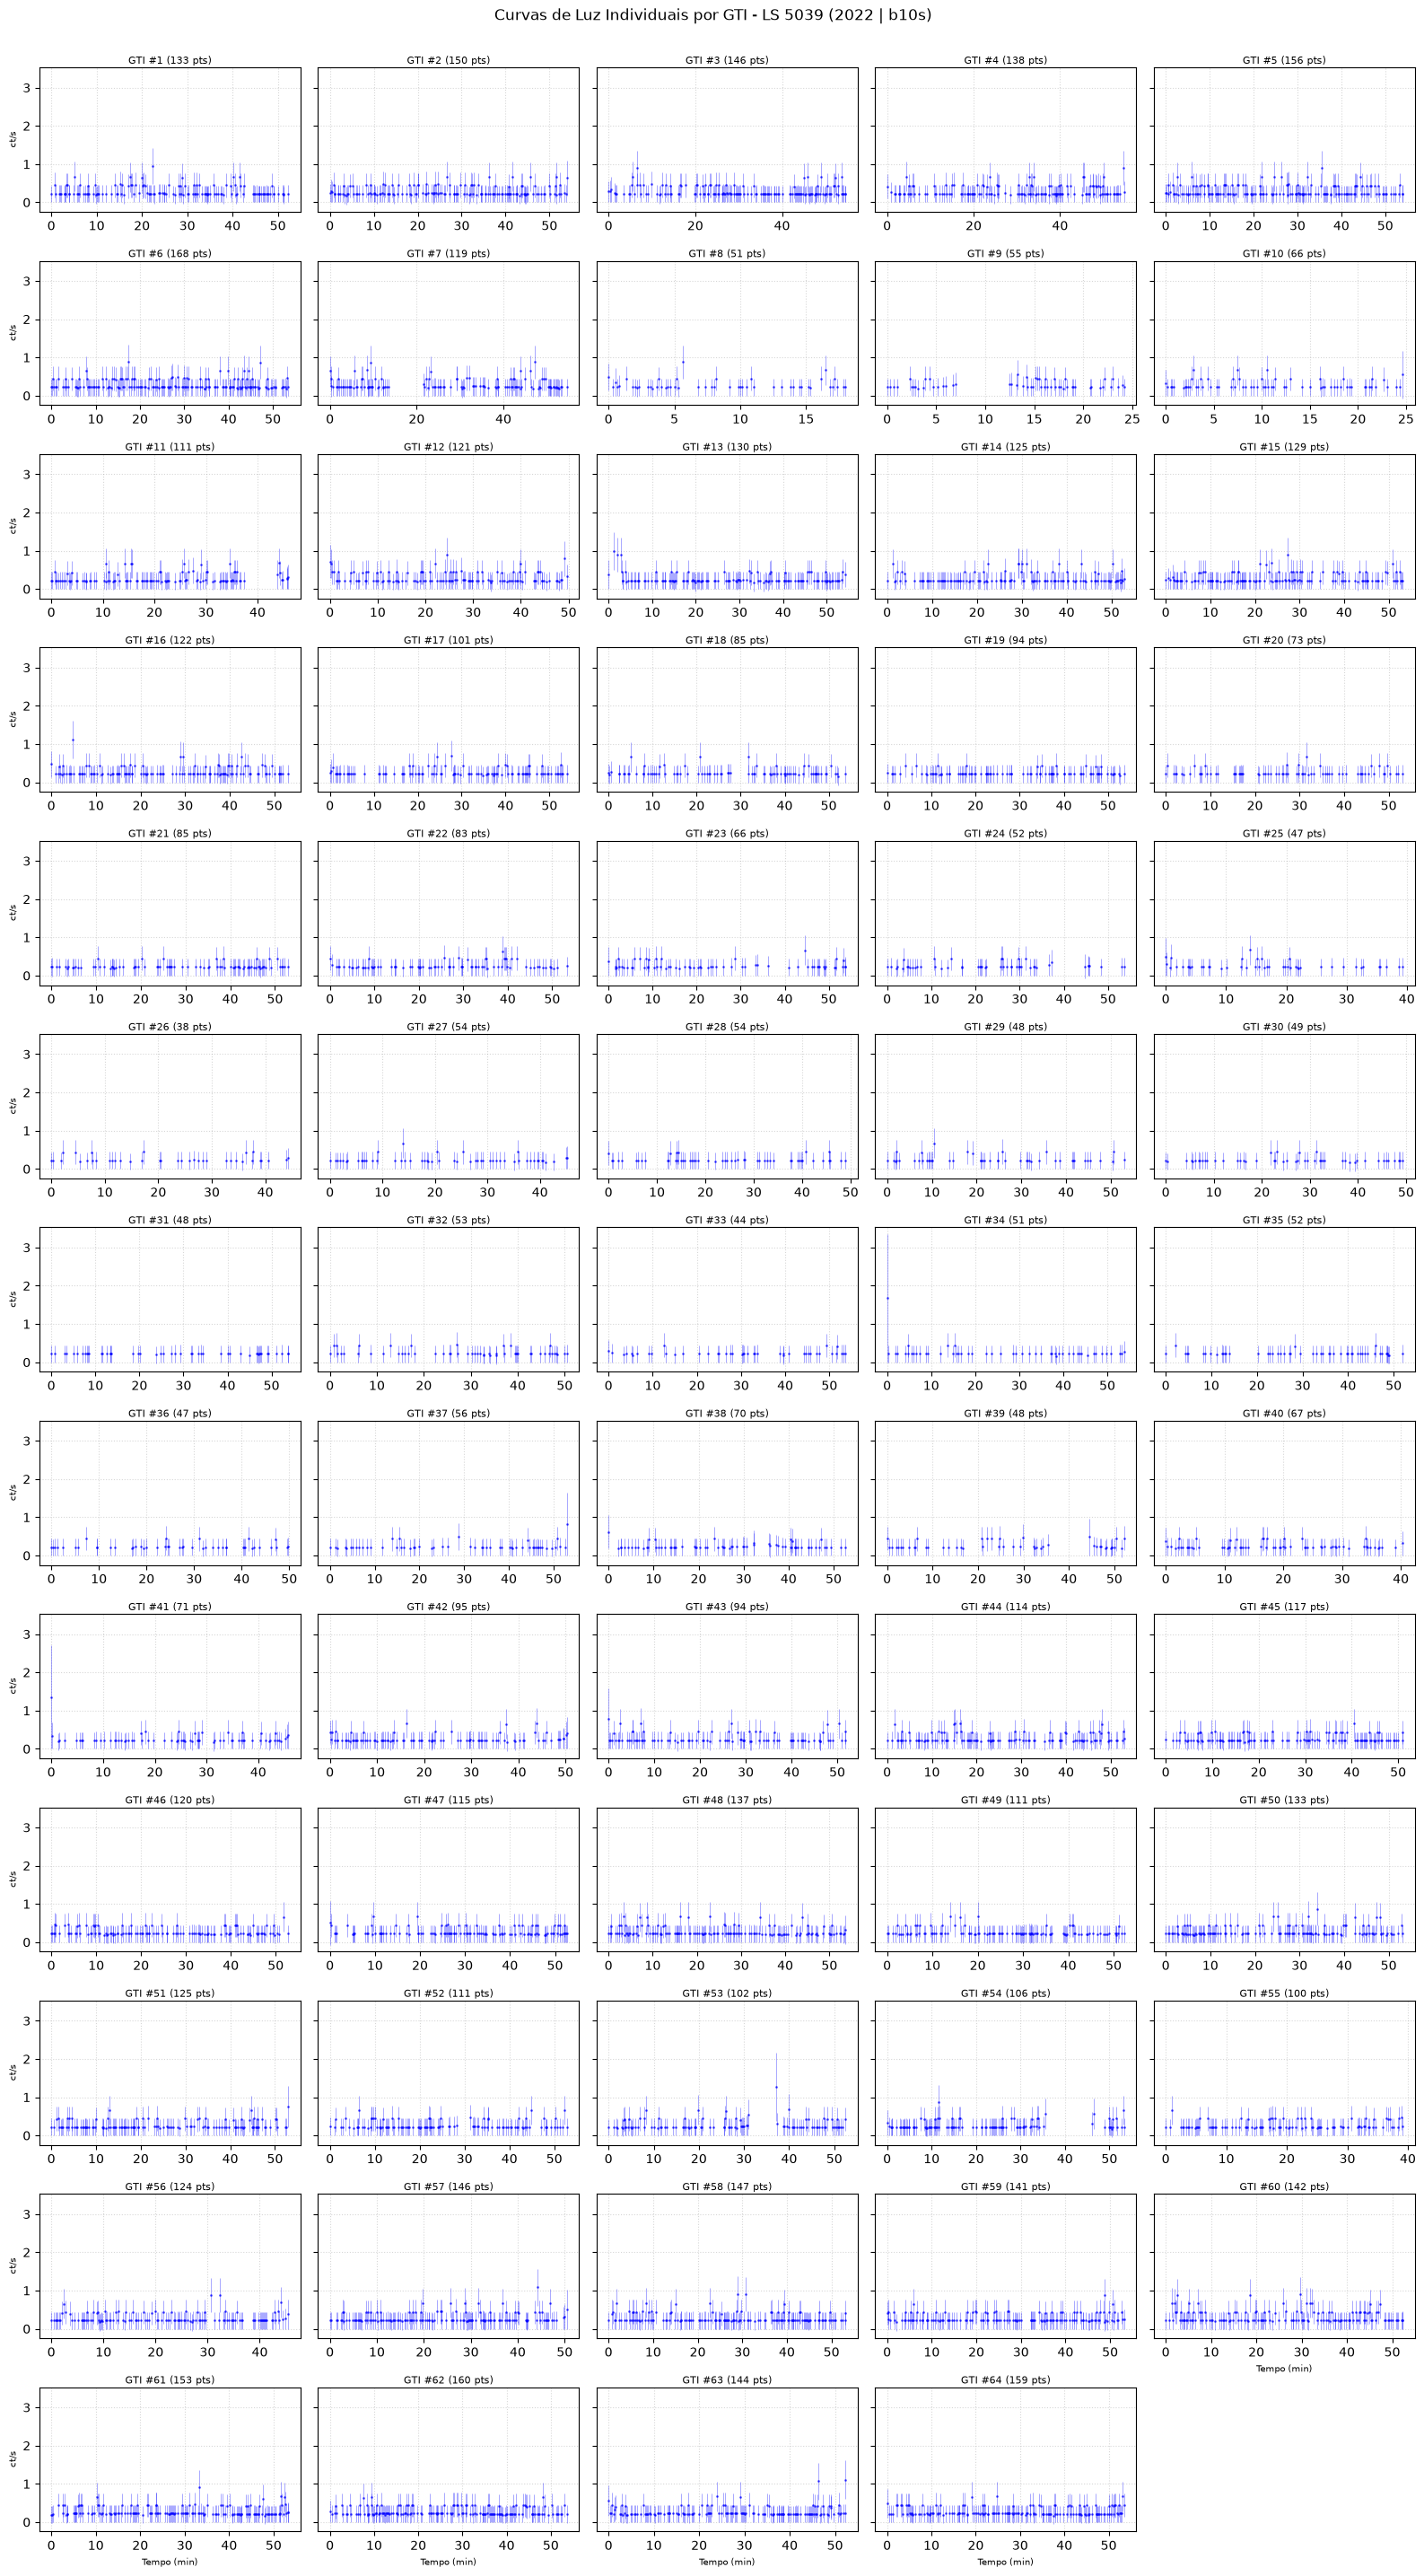

In [29]:
ncols = 5
nrows = int(np.ceil(n_seg / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.2), sharey=True)
axes = axes.flatten()

for i, (t_seg, r_seg, e_seg) in enumerate(segmentos):
    ax = axes[i]
    
    t_min = (t_seg - t_seg[0]) / 60.0
    
    if e_seg is not None:
        ax.errorbar(t_min, r_seg, yerr=e_seg, fmt='b.', alpha=0.6, markersize=2, elinewidth=0.4)
    else:
        ax.plot(t_min, r_seg, 'b.', alpha=0.6, markersize=2)
        
    ax.set_title(f'GTI #{i+1} ({len(t_seg)} pts)', fontsize=8, pad=3)
    ax.grid(True, ls=':', alpha=0.5)
    
    if i % ncols == 0:
        ax.set_ylabel('ct/s', fontsize=7)
    if i >= n_seg - ncols:
        ax.set_xlabel('Tempo (min)', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Curvas de Luz Individuais por GTI - LS 5039 ({ano} | {binagem})', fontsize=12, y=1.002)
plt.tight_layout()
plt.show()

Número de frequências independentes (N_ind): 11998.8
Média de pontos por GTI (N_médio): 99.2
Limiar FAP 1%   (Astropy): 0.2821
Limiar FAP 0.1% (Astropy): 0.3285


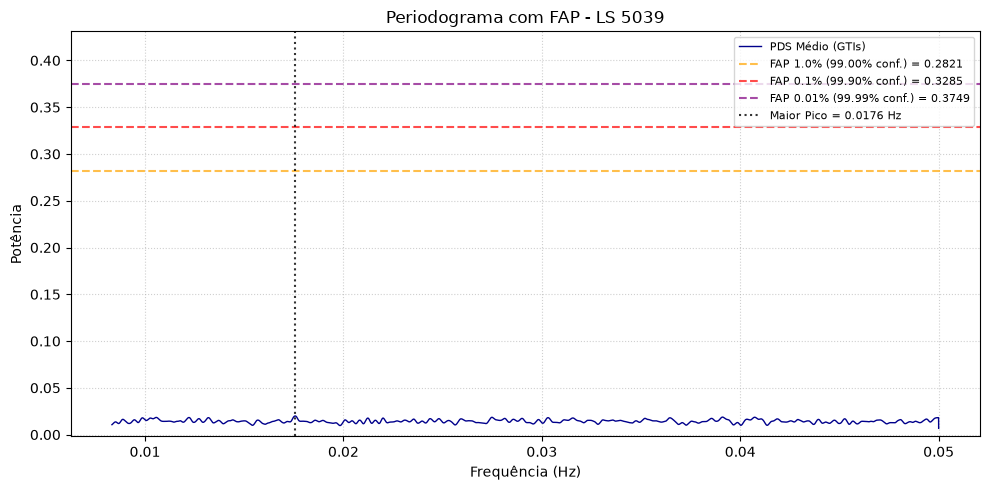

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def calcular_limiares_fap_scargle_astropy(freq_grid, n_pontos_medio, faps=[0.01, 0.001, 0.0001]):
    
    df = np.median(np.diff(freq_grid))
    f_max = np.max(freq_grid)
    n_ind = f_max / df
    
    limiares = {}
    for fap in faps:
        z_crit = np.log(n_ind) - np.log(fap)
        
        p_astropy = (2.0 * z_crit) / n_pontos_medio
        limiares[fap] = p_astropy
        
    return limiares, n_ind

n_pontos_medio = df_gtis['N_Pontos'].mean()

limiares_fap, n_ind = calcular_limiares_fap_scargle_astropy(
    freq_hz, n_pontos_medio, faps=[0.01, 0.001, 0.0001]
)

print(f"Número de frequências independentes (N_ind): {n_ind:.1f}")
print(f"Média de pontos por GTI (N_médio): {n_pontos_medio:.1f}")
print(f"Limiar FAP 1%   (Astropy): {limiares_fap[0.01]:.4f}")
print(f"Limiar FAP 0.1% (Astropy): {limiares_fap[0.001]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(freq_hz, power_med, color='darkblue', lw=1.0, label='PDS Médio (GTIs)')

colors = ['orange', 'red', 'purple']
for (fap, p_val), col in zip(limiares_fap.items(), colors):
    plt.axhline(p_val, color=col, ls='--', alpha=0.7, 
                label=f'FAP {fap*100}% ({100*(1-fap):.2f}% conf.) = {p_val:.4f}')

plt.axvline(best_freq_hz, color='black', ls=':', alpha=0.8, 
            label=f'Maior Pico = {best_freq_hz:.4f} Hz')

plt.xlabel('Frequência (Hz)')
plt.ylabel('Potência')
plt.title(f'Periodograma com FAP - LS 5039')
plt.grid(True, ls=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=8)

plt.ylim(-0.002, max(np.max(power_med), max(limiares_fap.values())) * 1.15)

plt.tight_layout()
plt.show()